# PRISM Drug Repurposing Screen Analysis

This notebook analyzes raw plate-level PRISM Repurposing screen data from Corsello et al. 2020.

The goal is to start from raw per-well MFI measurements and build a reproducible analysis workflow for:

1. primary screen quality control,
2. primary screen normalization and hit calling,
3. hit triage for dose-response follow-up,
4. secondary screen quality control and normalization,
5. dose-response curve fitting,
6. selective killing analysis,
7. biomarker association and prediction,
8. mechanism exploration,
9. repurposing candidate prioritization.

This notebook preserves raw data unchanged. All processed outputs will be written to separate folders.

In [30]:
import sys

print(sys.executable)

c:\Users\shash\Desktop\Code for assignment\notebooks\.venv\Scripts\python.exe


In [31]:
import sys

print(sys.executable)

c:\Users\shash\Desktop\Code for assignment\notebooks\.venv\Scripts\python.exe


In [32]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl


'c:\Users\shash\Desktop\Code' is not recognized as an internal or external command,
operable program or batch file.


In [33]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl

'c:\Users\shash\Desktop\Code' is not recognized as an internal or external command,
operable program or batch file.


In [34]:
import sys

python_path = f'"{sys.executable}"'
print(python_path)

"c:\Users\shash\Desktop\Code for assignment\notebooks\.venv\Scripts\python.exe"


In [35]:
import sys

!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl

In [36]:
from pathlib import Path
import os
import textwrap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Project root folder
PROJECT_DIR = Path(r"C:\Users\shash\Desktop\Code for assignment")

# Main folders
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

REPORTS_DIR = PROJECT_DIR / "reports"

# Create folders if they do not already exist
for folder in [
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)

Project directory: C:\Users\shash\Desktop\Code for assignment
Raw data directory: C:\Users\shash\Desktop\Code for assignment\data\raw


In [38]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

sns.set_context("notebook")

print("Display settings loaded.")

Display settings loaded.


In [39]:
def inventory_files(folder):
    """
    Return a table of files in a folder without reading full file contents.
    """
    folder = Path(folder)

    rows = []
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            rows.append({
                "relative_path": path.relative_to(folder),
                "file_name": path.name,
                "suffix": path.suffix.lower(),
                "size_mb": path.stat().st_size / (1024 ** 2),
            })

    return pd.DataFrame(rows)


raw_inventory = inventory_files(RAW_DIR)

print(f"Found {len(raw_inventory)} files in raw data folder.")
raw_inventory

Found 23 files in raw data folder.


,relative_path,file_name,suffix,size_mb
0,CCLE_expression.csv,CCLE_expression.csv,.csv,286.563055
1,CCLE_gene_cn.csv,CCLE_gene_cn.csv,.csv,637.766252
2,CCLE_mutations.csv,CCLE_mutations.csv,.csv,276.733011
3,features\Confounders.csv,Confounders.csv,.csv,0.060482
4,features\Copy Number Alterations.csv,Copy Number Alterations.csv,.csv,165.357536
5,features\CRISPR.csv,CRISPR.csv,.csv,117.430954
6,features\D2.csv,D2.csv,.csv,152.287231
7,features\Hotspot Mutations.csv,Hotspot Mutations.csv,.csv,118.464334
8,features\Metabolomics.csv,Metabolomics.csv,.csv,3.036568
9,features\Methylation.csv,Methylation.csv,.csv,246.978885


In [40]:
def preview_csv(path, nrows=5):
    """
    Safely preview a CSV file without loading the full dataset.
    Useful for checking column names and structure before analysis.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    preview = pd.read_csv(path, nrows=nrows)

    print(f"File: {path.name}")
    print(f"Preview rows: {preview.shape[0]}")
    print(f"Preview columns: {preview.shape[1]}")
    print("\nColumn names:")
    for col in preview.columns[:30]:
        print(f"  - {col}")

    if preview.shape[1] > 30:
        print(f"  ... {preview.shape[1] - 30} more columns")

    return preview


In [41]:
def preview_text_file(path, max_lines=40):
    """
    Preview the beginning of a text or README file.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with open(path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    print(f"File: {path.name}")
    print(f"Total lines shown: {min(len(lines), max_lines)}")
    print("-" * 80)

    for line in lines[:max_lines]:
        print(line.rstrip())

In [42]:
raw_inventory

,relative_path,file_name,suffix,size_mb
0,CCLE_expression.csv,CCLE_expression.csv,.csv,286.563055
1,CCLE_gene_cn.csv,CCLE_gene_cn.csv,.csv,637.766252
2,CCLE_mutations.csv,CCLE_mutations.csv,.csv,276.733011
3,features\Confounders.csv,Confounders.csv,.csv,0.060482
4,features\Copy Number Alterations.csv,Copy Number Alterations.csv,.csv,165.357536
5,features\CRISPR.csv,CRISPR.csv,.csv,117.430954
6,features\D2.csv,D2.csv,.csv,152.287231
7,features\Hotspot Mutations.csv,Hotspot Mutations.csv,.csv,118.464334
8,features\Metabolomics.csv,Metabolomics.csv,.csv,3.036568
9,features\Methylation.csv,Methylation.csv,.csv,246.978885


## 0.1 Inspect README and File Schemas

Before loading the large raw MFI matrices, we first inspect the README and small metadata files. This prevents us from guessing column names or making assumptions about how wells, compounds, doses, plates, pools, and cell lines are encoded.

In [43]:
preview_text_file(RAW_DIR / "README.md", max_lines=80)

File: README.md
Total lines shown: 80
--------------------------------------------------------------------------------
# PRISM Repurposing Screen Data Bundle

## Provenance

Raw screening data from Corsello et al. 2020 (Nature Cancer):
"Discovering the anti-cancer potential of non-oncology drugs by systematic
viability profiling"

DOI: 10.1038/s43018-019-0018-6
Data source: https://depmap.org/repurposing

## Assay

PRISM (Profiling Relative Inhibition Simultaneously in Mixtures) is a
multiplexed cell viability assay. Cancer cell lines are labeled with unique
DNA barcodes, pooled in groups of ~25 (matched by doubling time), and treated
with compounds. After 5 days of incubation, cells are lysed and barcode
abundance is measured via Luminex bead-based detection. The median
fluorescence intensity (MFI) of each barcode serves as a surrogate for the
relative viability of that cell line.

## Screens

**Primary screen:** 4,518 compounds tested at a single dose (2.5 uM) across
578 cell lines i

In [44]:
primary_treatment_preview = preview_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv",
    nrows=5
)

primary_cell_line_preview = preview_csv(
    RAW_DIR / "primary-screen-cell-line-info.csv",
    nrows=5
)

primary_pooling_preview = preview_csv(
    RAW_DIR / "primary-screen-pooling-info.csv",
    nrows=5
)

File: primary-screen-replicate-treatment-info.csv
Preview rows: 5
Preview columns: 18

Column names:
  - column_name
  - broad_id
  - name
  - dose
  - perturbation_type
  - screen_id
  - detection_plate
  - compound_plate
  - well
  - detection_plate_scan_time
  - vendor_id
  - purity
  - moa
  - target
  - disease.area
  - indication
  - smiles
  - phase
File: primary-screen-cell-line-info.csv
Preview rows: 5
Preview columns: 10

Column names:
  - row_name
  - depmap_id
  - ccle_name
  - primary_tissue
  - secondary_tissue
  - tertiary_tissue
  - passed_str_profiling
  - str_profiling_notes
  - originally_assigned_depmap_id
  - originally_assigned_ccle_name
File: primary-screen-pooling-info.csv
Preview rows: 5
Preview columns: 7

Column names:
  - row_name
  - screen_id
  - analyte_id
  - detection_pool
  - minipool_id
  - pool_id
  - passed_str_profiling


In [45]:
secondary_treatment_preview = preview_csv(
    RAW_DIR / "secondary-screen-replicate-treatment-info.csv",
    nrows=5
)

secondary_cell_line_preview = preview_csv(
    RAW_DIR / "secondary-screen-cell-line-info.csv",
    nrows=5
)

secondary_pooling_preview = preview_csv(
    RAW_DIR / "secondary-screen-pooling-info.csv",
    nrows=5
)

File: secondary-screen-replicate-treatment-info.csv
Preview rows: 5
Preview columns: 12

Column names:
  - column_name
  - broad_id
  - dose
  - screen_id
  - compound_plate
  - name
  - moa
  - target
  - disease.area
  - indication
  - smiles
  - phase
File: secondary-screen-cell-line-info.csv
Preview rows: 5
Preview columns: 7

Column names:
  - row_name
  - depmap_id
  - ccle_name
  - primary_tissue
  - secondary_tissue
  - tertiary_tissue
  - passed_str_profiling
File: secondary-screen-pooling-info.csv
Preview rows: 5
Preview columns: 9

Column names:
  - row_name
  - depmap_id
  - passed_str_profiling
  - ccle_name
  - screen_id
  - analyte_id
  - detection_pool
  - minipool_id
  - pool_id


In [46]:
primary_mfi_preview = preview_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=5
)

secondary_mfi_preview = preview_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=5
)

File: primary-screen-primary-mfi.csv
Preview rows: 5
Preview columns: 17059

Column names:
  - Unnamed: 0
  - PREP001_X1:A01::HTS
  - PREP001_X1:A02::HTS
  - PREP001_X1:A03::HTS
  - PREP001_X1:A04::HTS
  - PREP001_X1:A05::HTS
  - PREP001_X1:A06::HTS
  - PREP001_X1:A07::HTS
  - PREP001_X1:A08::HTS
  - PREP001_X1:A09::HTS
  - PREP001_X1:A10::HTS
  - PREP001_X1:A11::HTS
  - PREP001_X1:A12::HTS
  - PREP001_X1:A13::HTS
  - PREP001_X1:A14::HTS
  - PREP001_X1:A15::HTS
  - PREP001_X1:A16::HTS
  - PREP001_X1:A17::HTS
  - PREP001_X1:A18::HTS
  - PREP001_X1:A19::HTS
  - PREP001_X1:A20::HTS
  - PREP001_X1:A21::HTS
  - PREP001_X1:A22::HTS
  - PREP001_X1:A23::HTS
  - PREP001_X1:A24::HTS
  - PREP001_X1:B01::HTS
  - PREP001_X1:B02::HTS
  - PREP001_X1:B03::HTS
  - PREP001_X1:B04::HTS
  - PREP001_X1:B05::HTS
  ... 17029 more columns
File: secondary-screen-mfi.csv
Preview rows: 5
Preview columns: 48968

Column names:
  - Unnamed: 0
  - PMTS004_PR500.2_X1:A01::MTS005
  - PMTS004_PR500.2_X1:A02::MTS005
  -

In [47]:
primary_mfi_preview = preview_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=5
)

secondary_mfi_preview = preview_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=5
)

File: primary-screen-primary-mfi.csv
Preview rows: 5
Preview columns: 17059

Column names:
  - Unnamed: 0
  - PREP001_X1:A01::HTS
  - PREP001_X1:A02::HTS
  - PREP001_X1:A03::HTS
  - PREP001_X1:A04::HTS
  - PREP001_X1:A05::HTS
  - PREP001_X1:A06::HTS
  - PREP001_X1:A07::HTS
  - PREP001_X1:A08::HTS
  - PREP001_X1:A09::HTS
  - PREP001_X1:A10::HTS
  - PREP001_X1:A11::HTS
  - PREP001_X1:A12::HTS
  - PREP001_X1:A13::HTS
  - PREP001_X1:A14::HTS
  - PREP001_X1:A15::HTS
  - PREP001_X1:A16::HTS
  - PREP001_X1:A17::HTS
  - PREP001_X1:A18::HTS
  - PREP001_X1:A19::HTS
  - PREP001_X1:A20::HTS
  - PREP001_X1:A21::HTS
  - PREP001_X1:A22::HTS
  - PREP001_X1:A23::HTS
  - PREP001_X1:A24::HTS
  - PREP001_X1:B01::HTS
  - PREP001_X1:B02::HTS
  - PREP001_X1:B03::HTS
  - PREP001_X1:B04::HTS
  - PREP001_X1:B05::HTS
  ... 17029 more columns
File: secondary-screen-mfi.csv
Preview rows: 5
Preview columns: 48968

Column names:
  - Unnamed: 0
  - PMTS004_PR500.2_X1:A01::MTS005
  - PMTS004_PR500.2_X1:A02::MTS005
  -

In [48]:
# Confirm that the key files exist and preview their dimensions safely
key_files = [
    "primary-screen-primary-mfi.csv",
    "secondary-screen-mfi.csv",
    "primary-screen-replicate-treatment-info.csv",
    "secondary-screen-replicate-treatment-info.csv",
]

for file_name in key_files:
    path = RAW_DIR / file_name
    print(file_name)
    print("  Exists:", path.exists())
    print("  Size MB:", round(path.stat().st_size / (1024 ** 2), 2))
    print()

primary-screen-primary-mfi.csv
  Exists: True
  Size MB: 64.36

secondary-screen-mfi.csv
  Exists: True
  Size MB: 161.14

primary-screen-replicate-treatment-info.csv
  Exists: True
  Size MB: 4.93

secondary-screen-replicate-treatment-info.csv
  Exists: True
  Size MB: 3.61



In [49]:
# Read only headers and 2 rows from the two raw MFI matrices
primary_mfi_preview = pd.read_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=2
)

secondary_mfi_preview = pd.read_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=2
)

print("Primary MFI preview shape:", primary_mfi_preview.shape)
print("Primary first 5 columns:")
print(primary_mfi_preview.columns[:5].tolist())

print()

print("Secondary MFI preview shape:", secondary_mfi_preview.shape)
print("Secondary first 5 columns:")
print(secondary_mfi_preview.columns[:5].tolist())

Primary MFI preview shape: (2, 17059)
Primary first 5 columns:
['Unnamed: 0', 'PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS']

Secondary MFI preview shape: (2, 48968)
Secondary first 5 columns:
['Unnamed: 0', 'PMTS004_PR500.2_X1:A01::MTS005', 'PMTS004_PR500.2_X1:A02::MTS005', 'PMTS004_PR500.2_X1:A23::MTS005', 'PMTS004_PR500.2_X1:A24::MTS005']


In [50]:
primary_treatment = pd.read_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv"
)

secondary_treatment = pd.read_csv(
    RAW_DIR / "secondary-screen-replicate-treatment-info.csv"
)

print("Primary treatment shape:", primary_treatment.shape)
print("Secondary treatment shape:", secondary_treatment.shape)

display(primary_treatment.head())
display(secondary_treatment.head())

Primary treatment shape: (17058, 18)
Secondary treatment shape: (13008, 12)


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


,column_name,broad_id,dose,screen_id,compound_plate,name,moa,target,disease.area,indication,smiles,phase
0,BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00061,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
1,BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00244,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
2,BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00977,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
3,BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...,BRD-A25234499-001-19-1,0.03910,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
4,BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...,BRD-A25234499-001-19-1,0.15625,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched


## 1. Primary Screen QC: Initial Data Loading and Schema Validation

We begin with the primary screen because it is the single-dose screen used for initial hit discovery.

Before performing quality control or normalization, we validate the relationship between:

- the raw MFI matrix,
- treatment metadata,
- cell line metadata,
- pooling metadata.

The main goal here is to confirm that the well columns in the raw MFI matrix map cleanly to the treatment metadata.

In [76]:
primary_treatment = pd.read_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv"
)

primary_cell_lines = pd.read_csv(
    RAW_DIR / "primary-screen-cell-line-info.csv"
)

primary_pooling = pd.read_csv(
    RAW_DIR / "primary-screen-pooling-info.csv"
)

print("Primary treatment shape:", primary_treatment.shape)
print("Primary cell line info shape:", primary_cell_lines.shape)
print("Primary pooling info shape:", primary_pooling.shape)

Primary treatment shape: (17058, 18)
Primary cell line info shape: (588, 10)
Primary pooling info shape: (2637, 7)


In [77]:
primary_mfi = pd.read_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv"
)

print("Primary MFI shape:", primary_mfi.shape)
primary_mfi.head()

Primary MFI shape: (588, 17059)


,Unnamed: 0,PREP001_X1:A01::HTS,PREP001_X1:A02::HTS,PREP001_X1:A03::HTS,PREP001_X1:A04::HTS,PREP001_X1:A05::HTS,PREP001_X1:A06::HTS,PREP001_X1:A07::HTS,PREP001_X1:A08::HTS,PREP001_X1:A09::HTS,PREP001_X1:A10::HTS,PREP001_X1:A11::HTS,PREP001_X1:A12::HTS,PREP001_X1:A13::HTS,PREP001_X1:A14::HTS,PREP001_X1:A15::HTS,PREP001_X1:A16::HTS,PREP001_X1:A17::HTS,PREP001_X1:A18::HTS,PREP001_X1:A19::HTS,PREP001_X1:A20::HTS,PREP001_X1:A21::HTS,PREP001_X1:A22::HTS,PREP001_X1:A23::HTS,PREP001_X1:A24::HTS,PREP001_X1:B01::HTS,PREP001_X1:B02::HTS,PREP001_X1:B03::HTS,PREP001_X1:B04::HTS,PREP001_X1:B05::HTS,PREP001_X1:B06::HTS,PREP001_X1:B07::HTS,PREP001_X1:B08::HTS,PREP001_X1:B09::HTS,PREP001_X1:B10::HTS,PREP001_X1:B11::HTS,PREP001_X1:B12::HTS,PREP001_X1:B13::HTS,PREP001_X1:B14::HTS,PREP001_X1:B15::HTS,PREP001_X1:B16::HTS,PREP001_X1:B17::HTS,PREP001_X1:B18::HTS,PREP001_X1:B19::HTS,PREP001_X1:B20::HTS,PREP001_X1:B21::HTS,PREP001_X1:B22::HTS,PREP001_X1:B23::HTS,PREP001_X1:B24::HTS,PREP001_X1:C01::HTS,...,PMTS003_X3:D23::MTS004,PMTS003_X3:D24::MTS004,PMTS003_X3:E01::MTS004,PMTS003_X3:E02::MTS004,PMTS003_X3:E23::MTS004,PMTS003_X3:E24::MTS004,PMTS003_X3:F01::MTS004,PMTS003_X3:F02::MTS004,PMTS003_X3:F23::MTS004,PMTS003_X3:F24::MTS004,PMTS003_X3:G01::MTS004,PMTS003_X3:G02::MTS004,PMTS003_X3:G23::MTS004,PMTS003_X3:G24::MTS004,PMTS003_X3:H01::MTS004,PMTS003_X3:H02::MTS004,PMTS003_X3:H23::MTS004,PMTS003_X3:H24::MTS004,PMTS003_X3:I01::MTS004,PMTS003_X3:I02::MTS004,PMTS003_X3:I23::MTS004,PMTS003_X3:I24::MTS004,PMTS003_X3:J01::MTS004,PMTS003_X3:J02::MTS004,PMTS003_X3:J23::MTS004,PMTS003_X3:J24::MTS004,PMTS003_X3:K01::MTS004,PMTS003_X3:K02::MTS004,PMTS003_X3:K23::MTS004,PMTS003_X3:K24::MTS004,PMTS003_X3:L01::MTS004,PMTS003_X3:L02::MTS004,PMTS003_X3:L23::MTS004,PMTS003_X3:L24::MTS004,PMTS003_X3:M01::MTS004,PMTS003_X3:M02::MTS004,PMTS003_X3:M23::MTS004,PMTS003_X3:M24::MTS004,PMTS003_X3:N01::MTS004,PMTS003_X3:N02::MTS004,PMTS003_X3:N23::MTS004,PMTS003_X3:N24::MTS004,PMTS003_X3:O01::MTS004,PMTS003_X3:O02::MTS004,PMTS003_X3:O23::MTS004,PMTS003_X3:O24::MTS004,PMTS003_X3:P01::MTS004,PMTS003_X3:P02::MTS004,PMTS003_X3:P23::MTS004,PMTS003_X3:P24::MTS004
0,ACH-000001,109.0,213.0,236.0,473.0,330.5,221.5,189.0,193.0,240.0,170.0,144.0,146.0,213.0,231.5,219.0,99.0,248.0,100.0,225.0,160.5,197.0,178.5,82.5,201.0,105.0,251.0,245.0,257.0,310.0,172.0,258.0,157.5,218.0,270.0,272.5,357.5,194.0,189.0,251.5,234.0,189.0,778.0,161.5,283.5,234.0,366.0,93.0,240.0,203.5,...,301.5,723.0,662.5,1368.0,1675.0,1479.0,1186.0,1205.0,1450.0,1905.0,259.0,1146.5,374.0,828.0,287.0,847.5,380.0,766.0,244.0,1225.0,253.0,1295.5,302.0,1066.5,310.0,1146.5,250.0,1044.0,291.0,793.0,254.5,1432.0,324.0,1190.0,219.5,1603.0,258.5,1232.5,215.0,1291.0,232.0,648.0,250.5,850.0,504.5,1701.0,227.0,891.0,327.0,941.0
1,ACH-000007,1146.5,7813.0,8026.0,3724.5,12754.0,4377.0,5263.5,2245.0,9574.5,4939.5,6564.0,9023.0,8359.0,6808.5,5095.5,2850.5,1751.0,4465.5,8489.0,2843.0,10100.0,4575.0,2946.5,5852.0,223.5,11128.0,7122.0,432.5,3432.0,11825.5,3195.5,6416.0,7443.0,4564.0,3136.0,2009.5,3548.0,5541.0,3519.5,4145.0,1833.0,7658.0,1946.5,2813.0,2155.0,9328.5,1758.0,4006.0,166.5,...,263.0,1546.0,3818.0,6145.0,2860.0,2485.0,2115.5,3517.0,2363.5,5914.0,421.0,8854.5,247.0,1745.5,401.0,3774.0,250.0,3231.0,411.5,2466.0,614.0,2257.0,234.0,5617.0,493.5,4153.0,339.0,4518.5,1074.0,3431.0,270.0,4887.5,319.0,6459.0,282.0,3154.5,366.0,5107.0,392.0,3818.0,410.0,4930.0,265.0,2840.0,704.0,2713.0,259.5,7866.0,294.5,2573.5
2,ACH-000008,1311.0,10793.0,18787.0,18510.0,20980.0,17541.0,15048.0,18291.0,12060.5,14637.0,15335.0,14257.5,11498.0,11561.5,17263.0,15826.0,13934.5,23288.0,20691.0,18072.0,22006.5,17218.0,9776.0,12769.0,289.0,15484.0,19987.0,988.0,24026.0,16566.0,18141.0,17102.0,11595.0,16816.0,19987.0,19387.5,14313.0,10045.5,19387.0,18487.0,17518.0,12536.0,20357.0,15935.0,14118.0,10721.0,4730.5,18302.0,527.0,...,973.5,4443.0,5196.0,3545.0,8108.0,7196.0,5618.0,3946.0,4299.0,4853.5,205.0,9667.0,482.0,3333.0,590.0,6146.0,455.0,5685.0,283.0,6904.5,34

In [78]:
# Identify the row identifier column without renaming it
primary_row_id_col = primary_mfi.columns[0]

print("Primary MFI row ID column:", primary_row_id_col)

mfi_well_columns = primary_mfi.columns.drop(primary_row_id_col)
metadata_columns = primary_treatment["column_name"]

print("Number of MFI well columns:", len(mfi_well_columns))
print("Number of treatment metadata rows:", len(metadata_columns))

mfi_not_in_metadata = set(mfi_well_columns) - set(metadata_columns)
metadata_not_in_mfi = set(metadata_columns) - set(mfi_well_columns)

print("MFI columns missing from metadata:", len(mfi_not_in_metadata))
print("Metadata columns missing from MFI:", len(metadata_not_in_mfi))

Primary MFI row ID column: Unnamed: 0
Number of MFI well columns: 17058
Number of treatment metadata rows: 17058
MFI columns missing from metadata: 0
Metadata columns missing from MFI: 0


In [79]:
same_order = list(mfi_well_columns) == list(metadata_columns)

print("Do MFI well columns and treatment metadata rows have the same order?")
print(same_order)

Do MFI well columns and treatment metadata rows have the same order?
False


In [80]:
print("Primary perturbation types:")
display(primary_treatment["perturbation_type"].value_counts(dropna=False))

print("Primary number of unique compounds:")
print(primary_treatment["broad_id"].nunique(dropna=True))

print("Primary number of detection plates:")
print(primary_treatment["detection_plate"].nunique(dropna=True))

print("Primary number of compound plates:")
print(primary_treatment["compound_plate"].nunique(dropna=True))

print("Primary doses:")
display(primary_treatment["dose"].value_counts(dropna=False).sort_index())

Primary perturbation types:


perturbation_type
experimental_treatment    14082
vehicle_control            1518
positive_control           1458
Name: count, dtype: int64

Primary number of unique compounds:
4689
Primary number of detection plates:
48
Primary number of compound plates:
16
Primary doses:


dose
0.030000        6
0.250000       39
0.800000        3
0.910000        3
0.940000        3
             ... 
5.000000        9
5.600000        3
20.000000    1374
20.002434      84
NaN          1518
Name: count, Length: 419, dtype: int64

### 1.1 Align Primary Well Metadata to the MFI Matrix

The primary MFI matrix stores wells as columns. The treatment metadata tells us what each well column represents.

Because the MFI column order does not exactly match the treatment metadata row order, we align the metadata using `column_name`. This prevents incorrect assignment of compounds, controls, doses, or plates to MFI measurements.

In [81]:
# Build treatment metadata in the exact same order as the MFI well columns
primary_well_metadata = (
    primary_treatment
    .set_index("column_name")
    .loc[mfi_well_columns]
    .reset_index()
)

print("Aligned primary well metadata shape:", primary_well_metadata.shape)
display(primary_well_metadata.head())

Aligned primary well metadata shape: (17058, 18)


,index,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


In [82]:
alignment_ok = list(primary_well_metadata["column_name"]) == list(mfi_well_columns)

print("Metadata aligned to MFI columns:")
print(alignment_ok)

print("First 5 MFI well columns:")
print(list(mfi_well_columns[:5]))

print("\nFirst 5 aligned metadata column names:")
print(primary_well_metadata["column_name"].head().tolist())

KeyError: 'column_name'

In [ ]:
print("primary_treatment columns:")
print(primary_treatment.columns.tolist())

print("\nprimary_treatment index name:")
print(primary_treatment.index.name)

print("\nFirst 5 mfi_well_columns:")
print(list(mfi_well_columns[:5]))

primary_treatment columns:
['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']

primary_treatment index name:
None

First 5 mfi_well_columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [ ]:
# Build treatment metadata in the exact same order as the MFI well columns
primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("Aligned primary well metadata shape:", primary_well_metadata.shape)
print("Does column_name exist?", "column_name" in primary_well_metadata.columns)

display(primary_well_metadata.head())

Aligned primary well metadata shape: (17058, 18)
Does column_name exist? True


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


In [ ]:
alignment_ok = list(primary_well_metadata["column_name"]) == list(mfi_well_columns)

print("Metadata aligned to MFI columns:")
print(alignment_ok)

print("First 5 MFI well columns:")
print(list(mfi_well_columns[:5]))

print("\nFirst 5 aligned metadata column names:")
print(primary_well_metadata["column_name"].head().tolist())

Metadata aligned to MFI columns:
True
First 5 MFI well columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']

First 5 aligned metadata column names:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [ ]:
print("Duplicate column_name values in primary treatment metadata:")
print(primary_treatment["column_name"].duplicated().sum())

print("Duplicate MFI well columns:")
print(pd.Index(mfi_well_columns).duplicated().sum())

Duplicate column_name values in primary treatment metadata:
0
Duplicate MFI well columns:
0


In [ ]:
primary_plate_control_summary = (
    primary_well_metadata
    .groupby(["detection_plate", "perturbation_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(primary_plate_control_summary.head(10))

print("Number of detection plates:", primary_plate_control_summary.shape[0])

perturbation_type,detection_plate,experimental_treatment,positive_control,vehicle_control
0,PMTS001_X1,320,14,18
1,PMTS001_X2,320,14,18
2,PMTS001_X3,320,14,18
3,PMTS002_X1,219,28,36
4,PMTS002_X2,219,28,36
5,PMTS002_X3,219,28,36
6,PMTS003_X1,0,28,36
7,PMTS003_X2,0,28,36
8,PMTS003_X3,0,28,36
9,PREP001_X1,320,32,32


Number of detection plates: 48


In [ ]:
required_control_types = ["vehicle_control", "positive_control"]

for control_type in required_control_types:
    if control_type in primary_plate_control_summary.columns:
        missing_count = (primary_plate_control_summary[control_type] == 0).sum()
        print(f"Plates with no {control_type}: {missing_count}")
    else:
        print(f"{control_type} column is missing entirely.")

Plates with no vehicle_control: 0
Plates with no positive_control: 0


**Initial control check.** Every primary detection plate contains both vehicle controls and positive controls. This means each plate has the basic control structure needed for downstream plate-level QC and normalization. We should still assess whether the controls behave well, but no plate fails simply because controls are absent.

In [ ]:
# Separate the cell line identifiers from the raw MFI values
primary_cell_line_ids = primary_mfi[primary_row_id_col]
primary_mfi_values = primary_mfi[mfi_well_columns]

print("Number of primary cell line rows:", primary_cell_line_ids.shape[0])
print("Number of primary well columns:", primary_mfi_values.shape[1])

print("\nRaw MFI value summary:")
display(primary_mfi_values.stack().describe())

Number of primary cell line rows: 588
Number of primary well columns: 17058

Raw MFI value summary:


count    9.791433e+06
mean     4.020667e+03
std      4.997883e+03
min      0.000000e+00
25%      7.550000e+02
50%      2.239000e+03
75%      5.342500e+03
max      3.759040e+05
dtype: float64

In [ ]:
# Check missing values in the raw primary MFI matrix
missing_values_total = primary_mfi_values.isna().sum().sum()
missing_values_fraction = missing_values_total / primary_mfi_values.size

print("Total missing MFI values:", missing_values_total)
print("Fraction missing MFI values:", missing_values_fraction)

Total missing MFI values: 238671
Fraction missing MFI values: 0.023795466128765964


In [ ]:
primary_cell_line_ids = primary_mfi[primary_row_id_col]
primary_mfi_values = primary_mfi[mfi_well_columns]

print("Number of primary cell line rows:", primary_cell_line_ids.shape[0])
print("Number of primary well columns:", primary_mfi_values.shape[1])

print("\nRaw MFI value summary:")
display(primary_mfi_values.stack().describe())

Number of primary cell line rows: 588
Number of primary well columns: 17058

Raw MFI value summary:


count    9.791433e+06
mean     4.020667e+03
std      4.997883e+03
min      0.000000e+00
25%      7.550000e+02
50%      2.239000e+03
75%      5.342500e+03
max      3.759040e+05
dtype: float64

In [ ]:
missing_values_total = primary_mfi_values.isna().sum().sum()
missing_values_fraction = missing_values_total / primary_mfi_values.size

print("Total missing MFI values:", missing_values_total)
print("Fraction missing MFI values:", missing_values_fraction)

Total missing MFI values: 238671
Fraction missing MFI values: 0.023795466128765964


### 1.2 Raw Primary MFI Distribution

Raw MFI values are fluorescence intensity measurements. They are usually right-skewed, so we inspect both the raw scale and a log-transformed scale before deciding how to normalize.

This plot is descriptive only. We are not removing values yet.

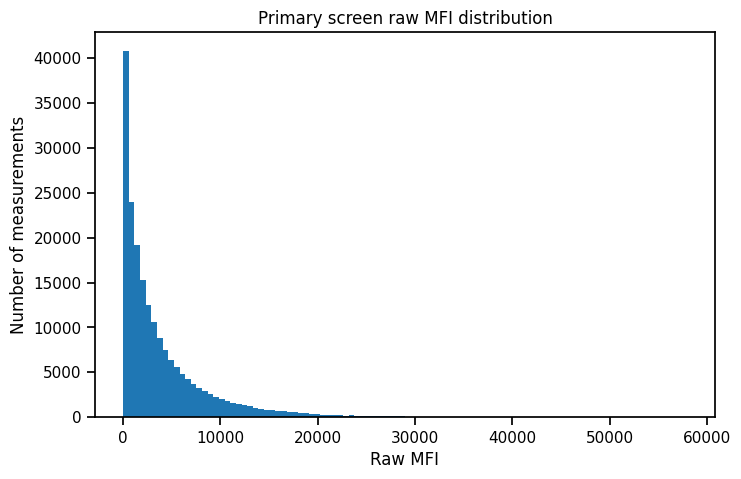

In [83]:
# Use a random sample so the plot is fast and readable
mfi_sample = primary_mfi_values.stack().sample(
    n=200_000,
    random_state=1
)

plt.figure(figsize=(8, 5))
plt.hist(mfi_sample, bins=100)
plt.xlabel("Raw MFI")
plt.ylabel("Number of measurements")
plt.title("Primary screen raw MFI distribution")
plt.show()

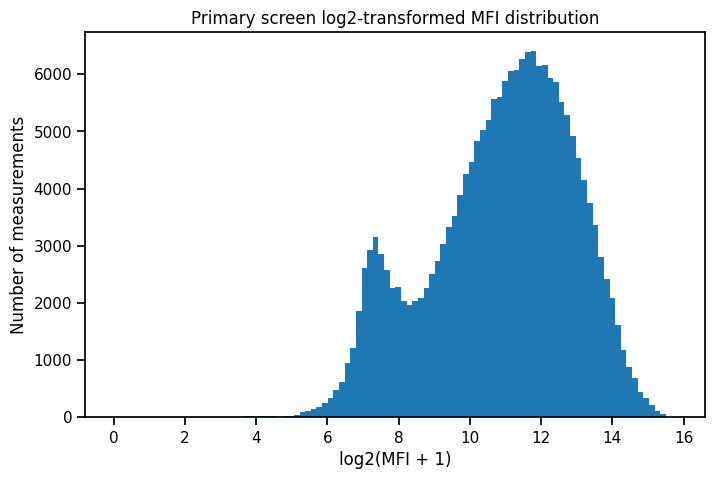

In [84]:
# Add 1 to avoid problems if any MFI values are zero
log2_mfi_sample = np.log2(mfi_sample + 1)

plt.figure(figsize=(8, 5))
plt.hist(log2_mfi_sample, bins=100)
plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of measurements")
plt.title("Primary screen log2-transformed MFI distribution")
plt.show()

In [85]:
non_positive_count = (primary_mfi_values <= 0).sum().sum()
non_positive_fraction = non_positive_count / primary_mfi_values.size

print("Non-positive MFI values:", non_positive_count)
print("Fraction non-positive MFI values:", non_positive_fraction)

Non-positive MFI values: 74
Fraction non-positive MFI values: 7.377789901281183e-06


### 1.3 Primary Control Behavior

Vehicle controls represent baseline viability under DMSO treatment. Positive controls are expected to reduce viability and therefore should generally produce lower MFI values.

A good screen should show separation between vehicle and positive controls. We first inspect this globally, then later at the plate and cell-line level.

In [86]:
vehicle_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "vehicle_control",
    "column_name"
].tolist()

positive_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "positive_control",
    "column_name"
].tolist()

experimental_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "experimental_treatment",
    "column_name"
].tolist()

print("Vehicle control wells:", len(vehicle_cols))
print("Positive control wells:", len(positive_cols))
print("Experimental treatment wells:", len(experimental_cols))

KeyError: 'column_name'

In [87]:
# Repair primary_well_metadata so column_name is preserved as a normal column

primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("primary_well_metadata shape:", primary_well_metadata.shape)
print("Columns:")
print(primary_well_metadata.columns.tolist())

print("\nDoes column_name exist?")
print("column_name" in primary_well_metadata.columns)

print("\nAlignment check:")
print(list(primary_well_metadata["column_name"]) == list(mfi_well_columns))

primary_well_metadata shape: (17058, 18)
Columns:
['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']

Does column_name exist?
True

Alignment check:
True


In [88]:
vehicle_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "vehicle_control",
    "column_name"
].tolist()

positive_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "positive_control",
    "column_name"
].tolist()

experimental_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "experimental_treatment",
    "column_name"
].tolist()

print("Vehicle control wells:", len(vehicle_cols))
print("Positive control wells:", len(positive_cols))
print("Experimental treatment wells:", len(experimental_cols))

Vehicle control wells: 1518
Positive control wells: 1458
Experimental treatment wells: 14082


In [89]:
vehicle_mfi_sample = primary_mfi_values[vehicle_cols].stack().sample(
    n=min(100_000, primary_mfi_values[vehicle_cols].stack().shape[0]),
    random_state=1
)

positive_mfi_sample = primary_mfi_values[positive_cols].stack().sample(
    n=min(100_000, primary_mfi_values[positive_cols].stack().shape[0]),
    random_state=1
)

control_mfi_summary = pd.DataFrame({
    "vehicle_control": vehicle_mfi_sample.describe(),
    "positive_control": positive_mfi_sample.describe(),
})

display(control_mfi_summary)

,vehicle_control,positive_control
count,97497.000000,97539.000000
mean,4330.305691,477.137212
std,5093.776256,1335.254137
min,15.000000,0.000000
25%,1028.000000,122.000000
50%,2562.000000,165.000000
75%,5708.000000,255.500000
max,59044.500000,50076.000000


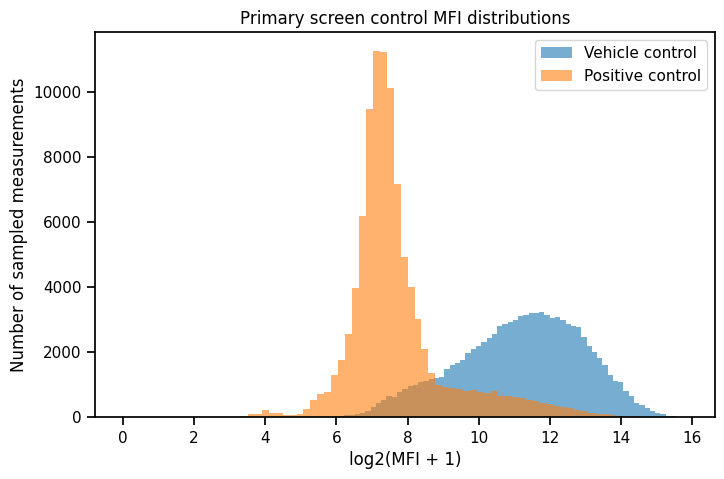

In [90]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log2(vehicle_mfi_sample + 1),
    bins=80,
    alpha=0.6,
    label="Vehicle control"
)

plt.hist(
    np.log2(positive_mfi_sample + 1),
    bins=80,
    alpha=0.6,
    label="Positive control"
)

plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of sampled measurements")
plt.title("Primary screen control MFI distributions")
plt.legend()
plt.show()

In [91]:
print("Median vehicle log2(MFI + 1):", np.log2(vehicle_mfi_sample + 1).median())
print("Median positive log2(MFI + 1):", np.log2(positive_mfi_sample + 1).median())
print("Difference, vehicle - positive:", np.log2(vehicle_mfi_sample + 1).median() - np.log2(positive_mfi_sample + 1).median())

Median vehicle log2(MFI + 1): 11.323617763291578
Median positive log2(MFI + 1): 7.3750394313469245
Difference, vehicle - positive: 3.9485783319446535
